# Multi-Disease Lung Pathology Detection from Chest X-Rays
## Using Deep Learning and Explainable AI
### Notebook 1: Exploratory Data Analysis (EDA)

---

**Dataset:** CheXpert v1.0-small — Stanford University ML Group  
**Authors:** Irvin et al., 2019 — *CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison*  
**DOI:** https://doi.org/10.71718/y7pj-4v93

---

## Notebook Overview

This notebook performs a thorough **Exploratory Data Analysis (EDA)** of the CheXpert chest X-ray dataset. The goal is to understand the structure, distribution, and characteristics of the data before any preprocessing or model training.

### Objectives
1. Load and inspect the training and validation CSV metadata files
2. Analyze the distribution of 14 pathology labels
3. Investigate uncertainty labels (`-1.0`) and missing values (`NaN`)
4. Explore patient demographics (age, sex)
5. Analyze image acquisition metadata (frontal vs lateral, AP vs PA)
6. Visualize sample X-ray images for each major pathology
7. Examine image resolution and aspect ratio statistics
8. Identify class imbalance issues

### Research Questions Addressed
- **RQ1:** What is the class distribution across 14 pathologies in CheXpert?
- **RQ2:** How prevalent are uncertainty labels, and how should they be handled?
- **RQ3:** Are there demographic biases in the dataset (age, sex)?
- **RQ4:** What preprocessing strategies are needed given the image variability?

In [ ]:
# Mount Google Drive — run this cell first
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/CheXpert_Project/outputs', exist_ok=True)
print('Drive mounted.')
print('data   :', os.path.exists('/content/drive/MyDrive/CheXpert_Project/data/train.csv'))
print('outputs:', os.path.exists('/content/drive/MyDrive/CheXpert_Project/outputs'))

Mounted at /content/drive
Drive mounted.
data   : True
outputs: True


---
## 1. Environment Setup & Library Imports

In [ ]:
# ─── Standard Library ───────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ─── Data Manipulation ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Image Processing ───────────────────────────────────────────────────────
import cv2
from PIL import Image

# ─── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ─── Plot Styling ───────────────────────────────────────────────────────────
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4
plt.rcParams['font.family']      = 'DejaVu Sans'
PALETTE = sns.color_palette('Blues_d', 14)

print('All libraries imported successfully.')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')
print(f'   OpenCV  : {cv2.__version__}')

All libraries imported successfully.
   NumPy   : 2.0.2
   Pandas  : 2.2.2
   OpenCV  : 4.13.0


---
## 2. Dataset Path Configuration

In [ ]:
# ─── Dataset Paths ──────────────────────────────────────────────────────────
BASE_PATH   = "/content/drive/MyDrive/CheXpert_Project/data"
TRAIN_CSV   = os.path.join(BASE_PATH, "train.csv")
VALID_CSV   = os.path.join(BASE_PATH, "valid.csv")
TRAIN_DIR   = os.path.join(BASE_PATH, "train")
VALID_DIR   = os.path.join(BASE_PATH, "valid")

# ─── 14 Pathology Label Columns ─────────────────────────────────────────────
LABEL_COLS = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture',
    'Support Devices'
]

# ─── Verify Structure ───────────────────────────────────────────────────────
print(' Dataset structure:')
for item in os.listdir(BASE_PATH):
    print(f'   {item}')

print(f'\n Base path confirmed: {BASE_PATH}')

 Dataset structure:
   valid.csv
   train.csv
   train
   valid

 Base path confirmed: /content/drive/MyDrive/CheXpert_Project/data


---
## 3. Load CSV Metadata Files

CheXpert provides two CSV files:
- **train.csv** — 223,414 studies used for model training
- **valid.csv** — 234 studies manually annotated by board-certified radiologists (gold standard)

In [ ]:
# ─── Load DataFrames ────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

print('=' * 55)
print('  CheXpert Dataset — Metadata Summary')
print('=' * 55)
print(f'  Training samples   : {len(train_df):>10,}')
print(f'  Validation samples : {len(valid_df):>10,}')
print(f'  Total samples      : {len(train_df)+len(valid_df):>10,}')
print(f'  Columns            : {len(train_df.columns):>10}')
print('=' * 55)

print('\n Column names:')
for col in train_df.columns:
    print(f'   • {col}')

  CheXpert Dataset — Metadata Summary
  Training samples   :    223,414
  Validation samples :        234
  Total samples      :    223,648
  Columns            :         19

 Column names:
   • Path
   • Sex
   • Age
   • Frontal/Lateral
   • AP/PA
   • No Finding
   • Enlarged Cardiomediastinum
   • Cardiomegaly
   • Lung Opacity
   • Lung Lesion
   • Edema
   • Consolidation
   • Pneumonia
   • Atelectasis
   • Pneumothorax
   • Pleural Effusion
   • Pleural Other
   • Fracture
   • Support Devices


In [ ]:
# ─── Preview Training Data ───────────────────────────────────────────────────
print(' First 5 rows of training metadata:')
train_df.head()

 First 5 rows of training metadata:


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [ ]:
# ─── Data Types & Memory Usage ───────────────────────────────────────────────
print(' DataFrame info:')
train_df.info()
print(f'\n Memory usage: {train_df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

 DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        223414 non-null  object 
 1   Sex                         223414 non-null  object 
 2   Age                         223414 non-null  int64  
 3   Frontal/Lateral             223414 non-null  object 
 4   AP/PA                       191027 non-null  object 
 5   No Finding                  22381 non-null   float64
 6   Enlarged Cardiomediastinum  44839 non-null   float64
 7   Cardiomegaly                46203 non-null   float64
 8   Lung Opacity                117778 non-null  float64
 9   Lung Lesion                 11944 non-null   float64
 10  Edema                       85956 non-null   float64
 11  Consolidation               70622 non-null   float64
 12  Pneumonia                   27608 non-null   float64
 1

---
## 4. Understanding the Label System

CheXpert uses a **ternary label system** — one of the key challenges of this dataset:

| Value  | Meaning    | Description |
|--------|------------|-------------|
| `1.0`  | Positive   | Pathology **present** |
| `0.0`  | Negative   | Pathology **absent** |
| `-1.0` | Uncertain  | Radiologist was **not certain** |
| `NaN`  | Not mentioned | Label was **not referenced** in the report |

In [ ]:
# ─── Label Value Counts ──────────────────────────────────────────────────────
print(' Label value distribution across all 14 pathology columns:\n')
print(f'{"Pathology":<35} {"Positive":>10} {"Negative":>10} {"Uncertain":>10} {"NaN":>10}')
print('-' * 75)

label_summary = []
for col in LABEL_COLS:
    pos  = (train_df[col] == 1.0).sum()
    neg  = (train_df[col] == 0.0).sum()
    unc  = (train_df[col] == -1.0).sum()
    nan  = train_df[col].isna().sum()
    total = len(train_df)
    label_summary.append({
        'Pathology': col,
        'Positive':  pos,
        'Negative':  neg,
        'Uncertain': unc,
        'NaN':       nan,
        'Pos_pct':   round(pos / total * 100, 1)
    })
    print(f'{col:<35} {pos:>10,} {neg:>10,} {unc:>10,} {nan:>10,}')

label_df = pd.DataFrame(label_summary)
print('-' * 75)
print(f'{"TOTAL":<35} {label_df["Positive"].sum():>10,} '
      f'{label_df["Negative"].sum():>10,} '
      f'{label_df["Uncertain"].sum():>10,} '
      f'{label_df["NaN"].sum():>10,}')

 Label value distribution across all 14 pathology columns:

Pathology                             Positive   Negative  Uncertain        NaN
---------------------------------------------------------------------------
No Finding                              22,381          0          0    201,033
Enlarged Cardiomediastinum              10,798     21,638     12,403    178,575
Cardiomegaly                            27,000     11,116      8,087    177,211
Lung Opacity                           105,581      6,599      5,598    105,636
Lung Lesion                              9,186      1,270      1,488    211,470
Edema                                   52,246     20,726     12,984    137,458
Consolidation                           14,783     28,097     27,742    152,792
Pneumonia                                6,039      2,799     18,770    195,806
Atelectasis                             33,376      1,328     33,739    154,971
Pneumothorax                            19,448     56,341      3

---
## 5. Visualizing Label Distribution

Understanding class imbalance is critical before training. A heavily imbalanced dataset can cause the model to predict only the majority class.

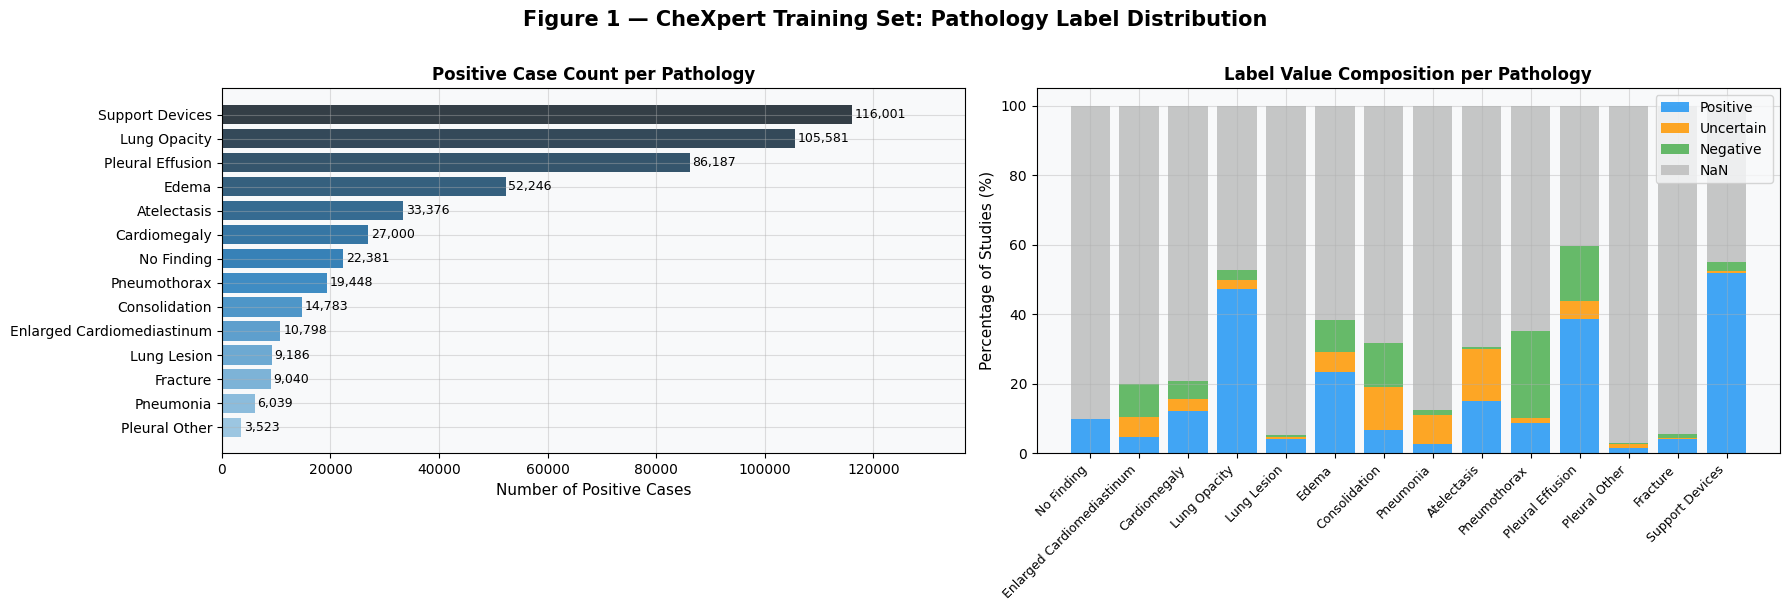

Figure saved: fig1_label_distribution.png


In [ ]:
# ─── Figure 1: Positive Label Prevalence ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Figure 1 — CheXpert Training Set: Pathology Label Distribution',
             fontsize=15, fontweight='bold', y=1.01)

# — Left: Positive counts bar chart —
ax1 = axes[0]
sorted_df = label_df.sort_values('Positive', ascending=True)
bars = ax1.barh(sorted_df['Pathology'], sorted_df['Positive'],
                color=sns.color_palette('Blues_d', len(LABEL_COLS)))
ax1.set_xlabel('Number of Positive Cases', fontsize=11)
ax1.set_title('Positive Case Count per Pathology', fontsize=12, fontweight='bold')
for bar, val in zip(bars, sorted_df['Positive']):
    ax1.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_xlim(0, sorted_df['Positive'].max() * 1.18)

# — Right: Stacked bar (Positive / Uncertain / Negative / NaN) —
ax2 = axes[1]
colors = ['#2196F3', '#FF9800', '#4CAF50', '#BDBDBD']
bottom = np.zeros(len(LABEL_COLS))
total  = len(train_df)
for key, color in zip(['Positive', 'Uncertain', 'Negative', 'NaN'], colors):
    vals = label_df.set_index('Pathology').loc[LABEL_COLS, key].values
    pct  = vals / total * 100
    ax2.bar(range(len(LABEL_COLS)), pct, bottom=bottom,
            color=color, label=key, alpha=0.85)
    bottom += pct

ax2.set_xticks(range(len(LABEL_COLS)))
ax2.set_xticklabels(LABEL_COLS, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Percentage of Studies (%)', fontsize=11)
ax2.set_title('Label Value Composition per Pathology', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('fig1_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: fig1_label_distribution.png')

---
## 6. Uncertainty Label Analysis

The **uncertainty label (`-1.0`)** is a distinctive feature of CheXpert. During training, we must decide how to handle these ambiguous cases. Two common strategies exist:

- **U-Zeros:** Map `-1.0` → `0.0` (treat uncertain as negative — more conservative)
- **U-Ones:** Map `-1.0` → `1.0` (treat uncertain as positive — more sensitive)

Irvin et al. (2019) found that neither strategy works universally — different pathologies benefit from different approaches.

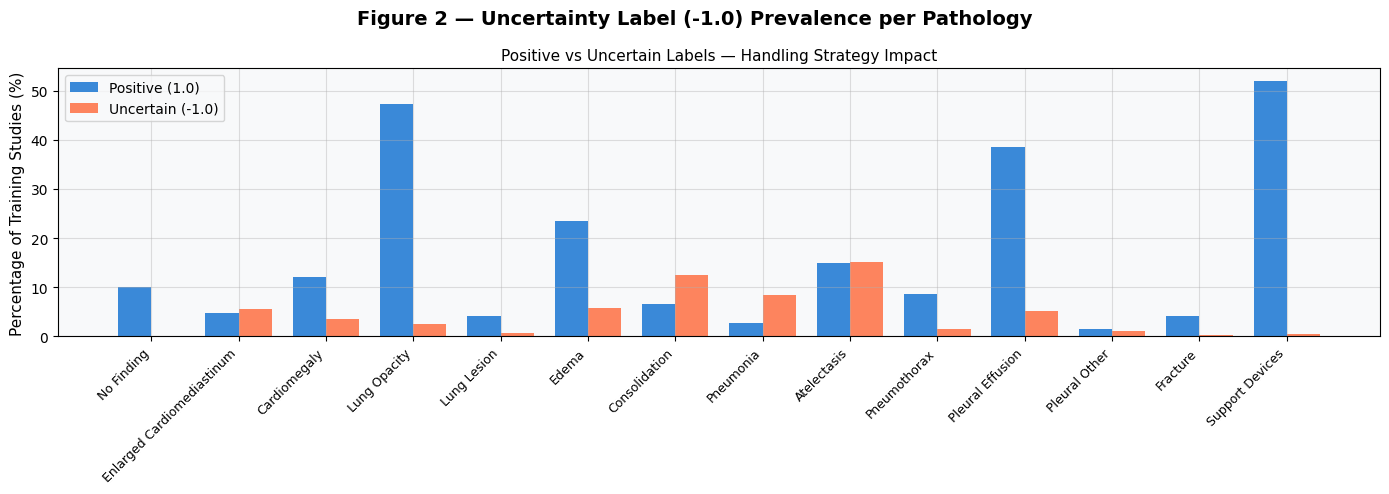


 Uncertainty Summary:
   Total uncertain labels : 139,958
   Total labeled entries  : 849,822
   Uncertainty rate       : 16.5%


In [ ]:
# ─── Uncertainty Analysis ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Figure 2 — Uncertainty Label (-1.0) Prevalence per Pathology',
             fontsize=14, fontweight='bold')

unc_pct = [(train_df[col] == -1.0).sum() / len(train_df) * 100
           for col in LABEL_COLS]
pos_pct = [(train_df[col] == 1.0).sum()  / len(train_df) * 100
           for col in LABEL_COLS]

x = np.arange(len(LABEL_COLS))
width = 0.38
ax.bar(x - width/2, pos_pct, width, label='Positive (1.0)',  color='#1976D2', alpha=0.85)
ax.bar(x + width/2, unc_pct, width, label='Uncertain (-1.0)', color='#FF7043', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(LABEL_COLS, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Percentage of Training Studies (%)', fontsize=11)
ax.set_title('Positive vs Uncertain Labels — Handling Strategy Impact',
             fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig2_uncertainty_labels.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
total_uncertain = (train_df[LABEL_COLS] == -1.0).sum().sum()
total_labels    = train_df[LABEL_COLS].notna().sum().sum()
print(f'\n Uncertainty Summary:')
print(f'   Total uncertain labels : {total_uncertain:,}')
print(f'   Total labeled entries  : {total_labels:,}')
print(f'   Uncertainty rate       : {total_uncertain/total_labels*100:.1f}%')

---
## 7. Patient Demographics Analysis

Understanding the demographic characteristics of the dataset helps identify potential biases and informs the generalizability of trained models.

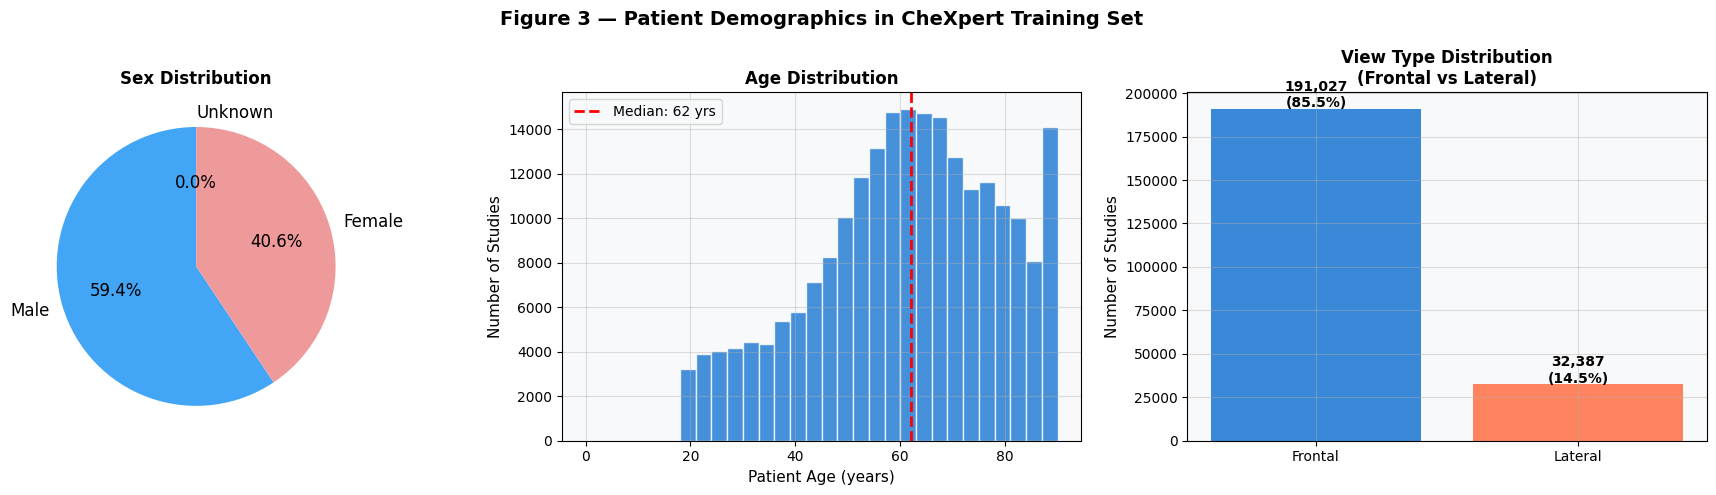

 Demographics Summary:
   Age  — Mean: 60.4 | Median: 62 | Std: 17.8 | Range: 0–90
   Sex  — Male: 132,636 (59.4%)
   Sex  — Female: 90,777 (40.6%)
   Sex  — Unknown: 1 (0.0%)


In [ ]:
# ─── Demographics ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 3 — Patient Demographics in CheXpert Training Set',
             fontsize=14, fontweight='bold')

# — Sex Distribution —
ax1 = axes[0]
sex_counts = train_df['Sex'].value_counts()
ax1.pie(sex_counts.values,
        labels=sex_counts.index,
        autopct='%1.1f%%',
        colors=['#42A5F5', '#EF9A9A'],
        startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('Sex Distribution', fontsize=12, fontweight='bold')

# — Age Distribution —
ax2 = axes[1]
train_df['Age'].hist(bins=30, ax=ax2, color='#1976D2',
                     alpha=0.8, edgecolor='white')
ax2.axvline(train_df['Age'].median(), color='red',
            linestyle='--', linewidth=2, label=f'Median: {train_df["Age"].median():.0f} yrs')
ax2.set_xlabel('Patient Age (years)', fontsize=11)
ax2.set_ylabel('Number of Studies', fontsize=11)
ax2.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

# — View Position —
ax3 = axes[2]
view_counts = train_df['Frontal/Lateral'].value_counts()
ax3.bar(view_counts.index, view_counts.values,
        color=['#1976D2', '#FF7043'], alpha=0.85)
for i, (idx, val) in enumerate(view_counts.items()):
    ax3.text(i, val + 1000, f'{val:,}\n({val/len(train_df)*100:.1f}%)',
             ha='center', fontsize=10, fontweight='bold')
ax3.set_ylabel('Number of Studies', fontsize=11)
ax3.set_title('View Type Distribution\n(Frontal vs Lateral)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Demographics Summary:')
print(f'   Age  — Mean: {train_df["Age"].mean():.1f} | '
      f'Median: {train_df["Age"].median():.0f} | '
      f'Std: {train_df["Age"].std():.1f} | '
      f'Range: {train_df["Age"].min():.0f}–{train_df["Age"].max():.0f}')
for sex, cnt in sex_counts.items():
    print(f'   Sex  — {sex}: {cnt:,} ({cnt/len(train_df)*100:.1f}%)')

---
## 8. Image Acquisition Analysis

CheXpert contains both **frontal** and **lateral** views, as well as AP (Anterior-Posterior) and PA (Posterior-Anterior) projections for frontal images. This distinction matters clinically and for model training.

> **Note:** For this project, we will focus exclusively on **frontal (AP/PA) views** to maintain consistency and reduce confounding variability.

 Image Acquisition Summary:
   Total studies      : 223,414
   Frontal views      : 191,027 (85.5%)
   Lateral views      : 32,387 (14.5%)

   Frontal projection breakdown:
     AP   : 161,590 (84.6%)
     PA   : 29,420 (15.4%)
     LL   : 16 (0.0%)
     RL   : 1 (0.0%)


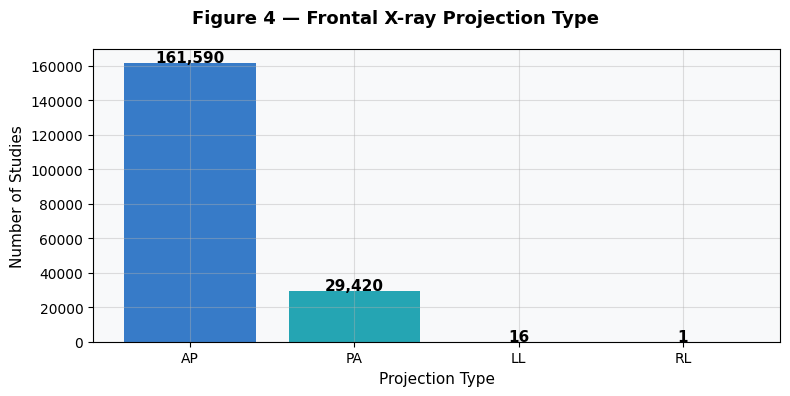

In [ ]:
# ─── AP vs PA Analysis ───────────────────────────────────────────────────────
frontal_df  = train_df[train_df['Frontal/Lateral'] == 'Frontal'].copy()
lateral_df  = train_df[train_df['Frontal/Lateral'] == 'Lateral'].copy()

print(' Image Acquisition Summary:')
print(f'   Total studies      : {len(train_df):,}')
print(f'   Frontal views      : {len(frontal_df):,} ({len(frontal_df)/len(train_df)*100:.1f}%)')
print(f'   Lateral views      : {len(lateral_df):,} ({len(lateral_df)/len(train_df)*100:.1f}%)')
print()

ap_pa = frontal_df['AP/PA'].value_counts()
print('   Frontal projection breakdown:')
for proj, cnt in ap_pa.items():
    print(f'     {proj:5s}: {cnt:,} ({cnt/len(frontal_df)*100:.1f}%)')

# Plot AP/PA distribution
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Figure 4 — Frontal X-ray Projection Type',
             fontsize=13, fontweight='bold')
bars = ax.bar(ap_pa.index, ap_pa.values,
              color=['#1565C0', '#0097A7', '#558B2F'], alpha=0.85)
for bar, val in zip(bars, ap_pa.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Number of Studies', fontsize=11)
ax.set_xlabel('Projection Type', fontsize=11)
plt.tight_layout()
plt.savefig('fig4_projection_type.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Class Co-occurrence Analysis

In medical imaging, a patient often presents with **multiple simultaneous conditions** (multi-label problem). Understanding co-occurrence between pathologies informs model design.

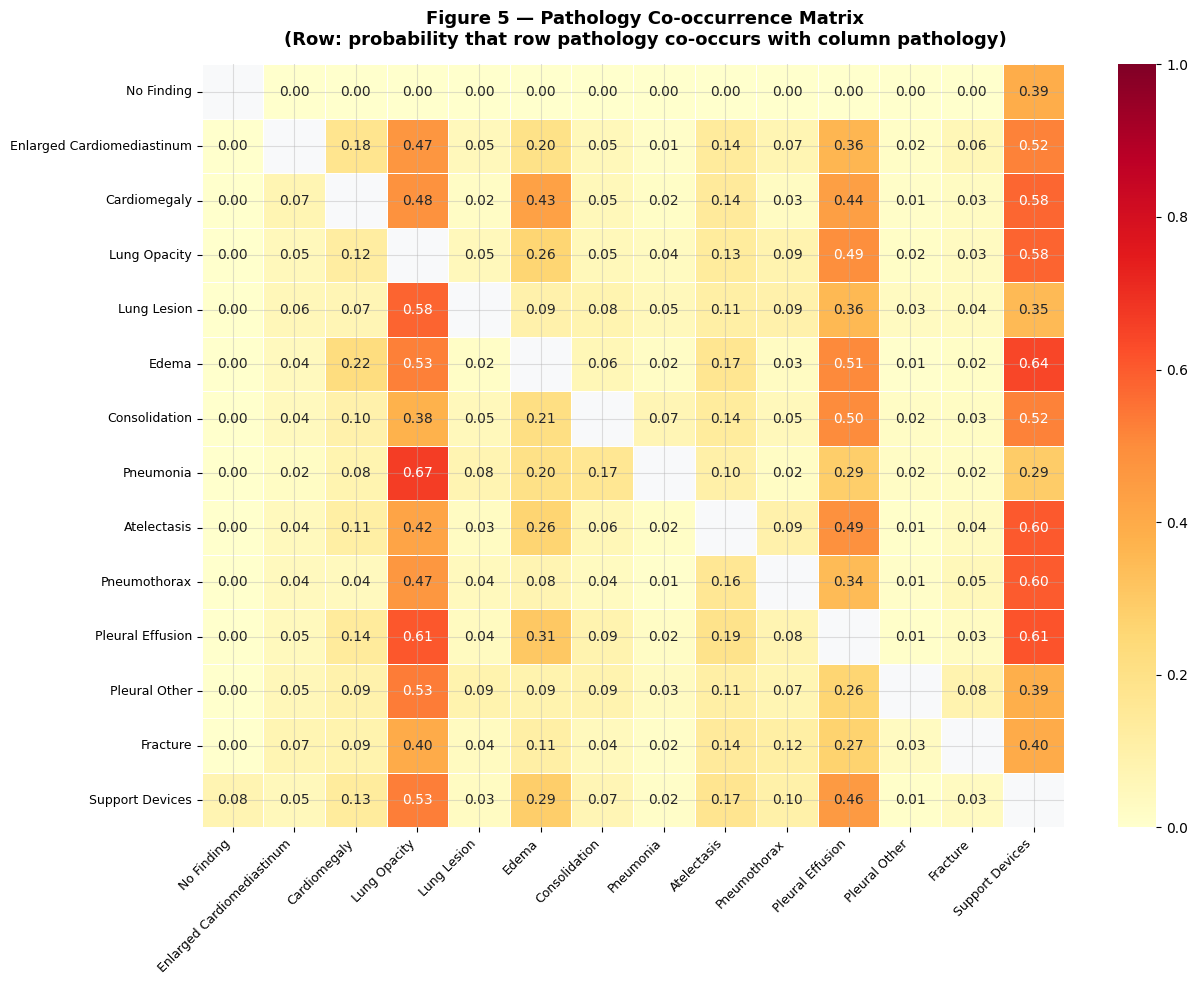

 Strongest pathology co-occurrences (positive labels only):
   Edema                               ↔ Support Devices                     : 0.64
   Pleural Effusion                    ↔ Support Devices                     : 0.61
   Atelectasis                         ↔ Support Devices                     : 0.60
   Pneumothorax                        ↔ Support Devices                     : 0.60
   Lung Opacity                        ↔ Support Devices                     : 0.58
   Cardiomegaly                        ↔ Support Devices                     : 0.58
   Consolidation                       ↔ Support Devices                     : 0.52
   Enlarged Cardiomediastinum          ↔ Support Devices                     : 0.52


In [ ]:
# ─── Co-occurrence Heatmap ───────────────────────────────────────────────────
# Use only positive labels (1.0) for co-occurrence
binary_df  = (train_df[LABEL_COLS] == 1.0).astype(int)
cooccur    = binary_df.T.dot(binary_df)
# Normalize by diagonal (self-count)
diag       = np.diag(cooccur.values)
cooccur_norm = cooccur.div(diag, axis=0)

fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Figure 5 — Pathology Co-occurrence Matrix\n'
             '(Row: probability that row pathology co-occurs with column pathology)',
             fontsize=13, fontweight='bold')

mask = np.eye(len(LABEL_COLS), dtype=bool)   # hide diagonal
sns.heatmap(cooccur_norm,
            annot=True, fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            mask=mask,
            ax=ax,
            xticklabels=LABEL_COLS,
            yticklabels=LABEL_COLS,
            vmin=0, vmax=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('fig5_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight strongest pairs
print(' Strongest pathology co-occurrences (positive labels only):')
pairs = []
for i, r in enumerate(LABEL_COLS):
    for j, c in enumerate(LABEL_COLS):
        if i < j:
            val = cooccur_norm.iloc[i, j]
            pairs.append((r, c, val))
pairs.sort(key=lambda x: x[2], reverse=True)
for r, c, v in pairs[:8]:
    print(f'   {r:<35} ↔ {c:<35} : {v:.2f}')

In [ ]:
import os
import pandas as pd

BASE_PATH = '/content/drive/MyDrive/CheXpert_Project/data'
train_df = pd.read_csv(os.path.join(BASE_PATH, 'train.csv'))

# Shfaq nje path shembull
sample = train_df[train_df['Cardiomegaly'] == 1.0].iloc[0]['Path']
print('CSV path    :', sample)

clean = sample.replace('CheXpert-v1.0-small/', '')
full  = os.path.join(BASE_PATH, clean)
print('Full path   :', full)
print('File exists :', os.path.exists(full))

# Shfaq cfare ka ne data folder
print('\nData folder:')
for item in os.listdir(BASE_PATH):
    print(' ', item)

CSV path    : CheXpert-v1.0-small/train/patient00007/study1/view1_frontal.jpg
Full path   : /content/drive/MyDrive/CheXpert_Project/data/train/patient00007/study1/view1_frontal.jpg
File exists : True

Data folder:
  valid.csv
  train.csv
  train
  valid


---
## 10. Sample X-Ray Image Visualization

Visual inspection of the raw images is essential to understand image quality, contrast, and the appearance of different pathologies.

In [ ]:
# ─── Helper: load image from CheXpert path ──────────────────────────────────
def load_chexpert_image(relative_path, base=BASE_PATH):
    """
    Load a CheXpert image given its CSV path.
    Strips the 'CheXpert-v1.0-small/' prefix and builds the full path.
    """
    clean  = relative_path.replace('CheXpert-v1.0-small/', '')
    full   = os.path.join(base, clean)
    img    = cv2.imread(full, cv2.IMREAD_GRAYSCALE)
    return img, full

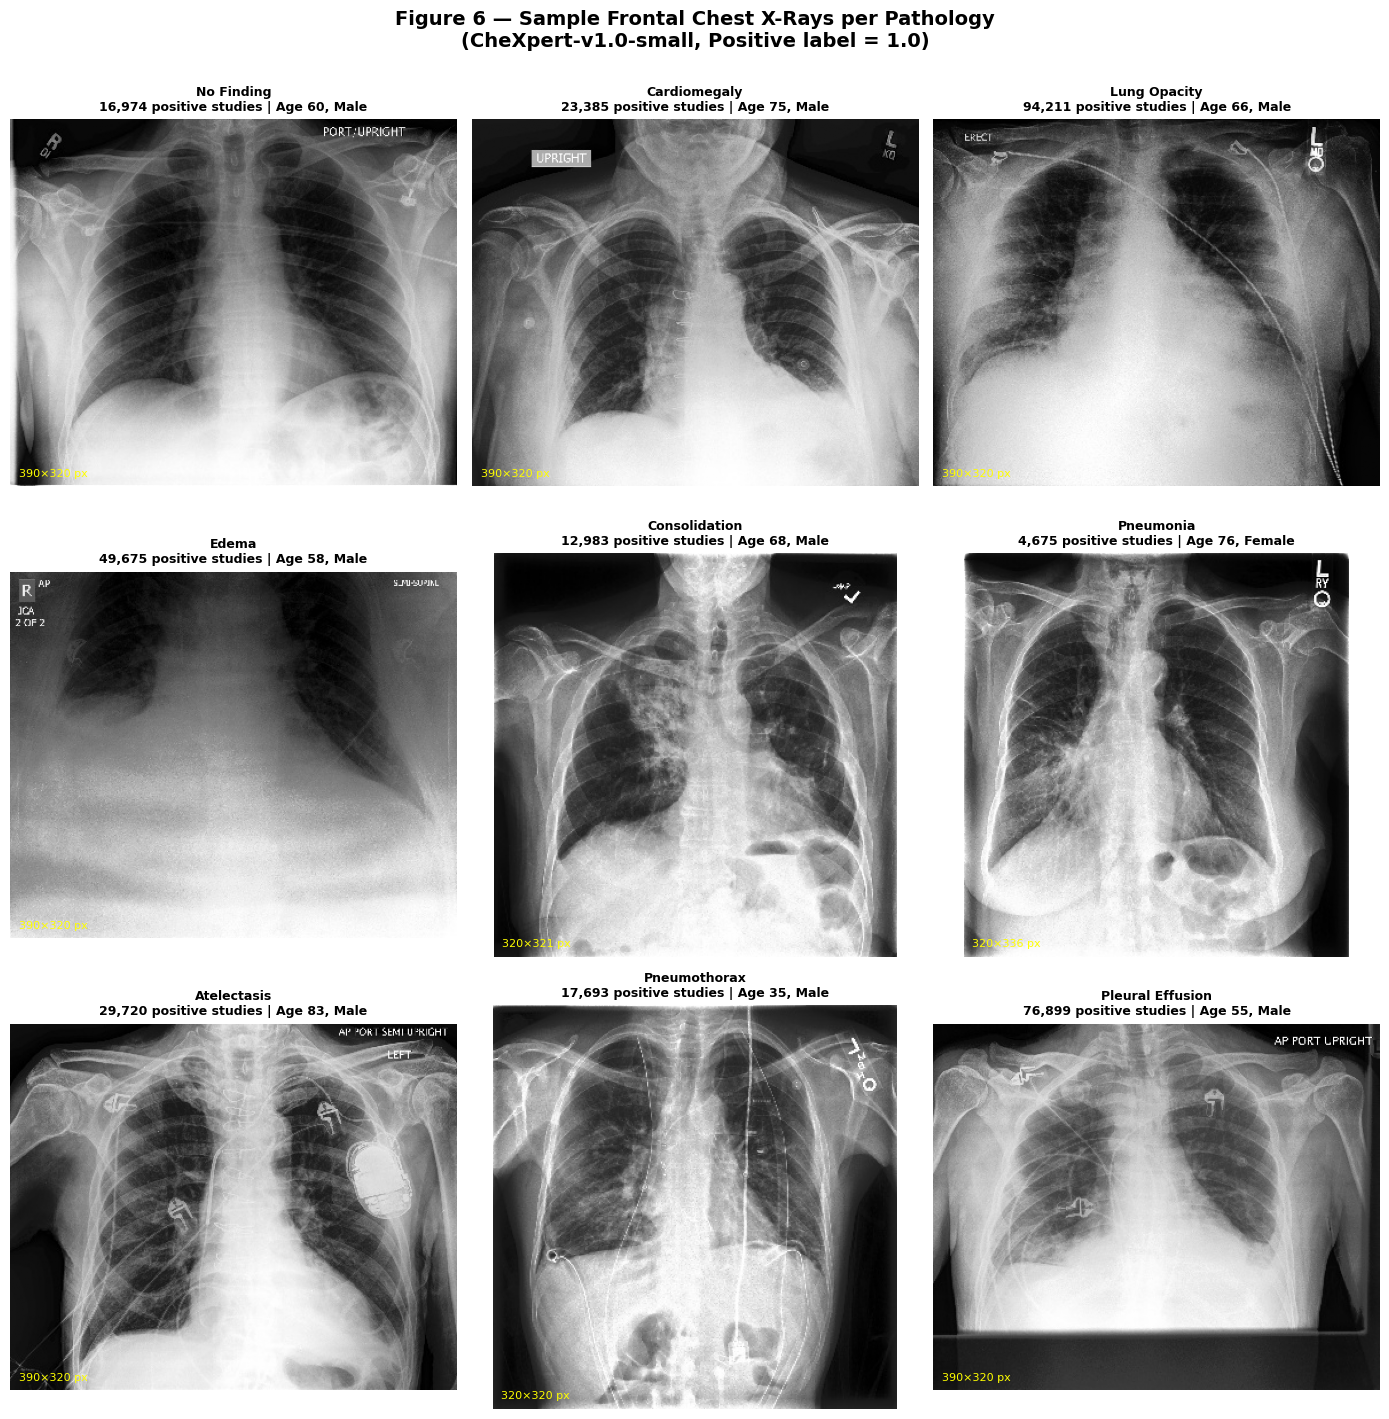

Figure saved: /content/drive/MyDrive/CheXpert_Project/outputs/fig6_sample_xrays.png


In [ ]:
# ─── Figure 6: Sample Images — One per Major Pathology ──────────────────────
SHOW_LABELS = [
    'No Finding', 'Cardiomegaly', 'Lung Opacity',
    'Edema', 'Consolidation', 'Pneumonia',
    'Atelectasis', 'Pneumothorax', 'Pleural Effusion'
]

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
fig.suptitle('Figure 6 — Sample Frontal Chest X-Rays per Pathology\n'
             '(CheXpert-v1.0-small, Positive label = 1.0)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, label in zip(axes.flatten(), SHOW_LABELS):
    subset = train_df[
        (train_df['Frontal/Lateral'] == 'Frontal') &
        (train_df[label] == 1.0)
    ].sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

    if len(subset) == 0:
        ax.axis('off')
        ax.set_title(f'{label}\n(no sample)', fontsize=9)
        continue

    # Try up to 20 rows until a readable image is found
    img, fpath, found_row = None, None, None
    for _, row in subset.head(20).iterrows():
        candidate, fp = load_chexpert_image(row['Path'])
        if candidate is not None:
            img, fpath, found_row = candidate, fp, row
            break

    if img is None:
        ax.axis('off')
        ax.set_title(f'{label}\n(file missing)', fontsize=9)
        continue

    ax.imshow(img, cmap='gray')
    ax.axis('off')
    n_pos = len(subset)
    ax.set_title(f'{label}\n{n_pos:,} positive studies | Age {found_row["Age"]:.0f}, {found_row["Sex"]}',
                 fontsize=9, fontweight='bold', pad=6)
    ax.text(0.02, 0.02, f'{img.shape[1]}×{img.shape[0]} px',
            transform=ax.transAxes, color='yellow', fontsize=8, va='bottom')

plt.tight_layout()
out = os.path.join('/content/drive/MyDrive/CheXpert_Project/outputs', 'fig6_sample_xrays.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved:', out)

---
## 11. Image Resolution & Aspect Ratio Analysis

CheXpert images vary in resolution. Before training, all images will be resized to **224×224 pixels** (standard input for ImageNet pre-trained models). Here we measure the natural distribution of resolutions to quantify information loss.

In [ ]:
# ─── Sample 300 images and measure resolution ───────────────────────────────
import random
random.seed(42)

frontal_sample = frontal_df.sample(min(300, len(frontal_df)),
                                    random_state=42)
heights, widths, aspects = [], [], []

print(' Sampling 300 frontal images for resolution analysis...')
for _, row in frontal_sample.iterrows():
    img, _ = load_chexpert_image(row['Path'])
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)
        aspects.append(w / h)

print(f'   Valid images sampled: {len(heights)}')
print(f'\n📐 Resolution Statistics:')
print(f'   Height — Mean: {np.mean(heights):.0f} | '
      f'Min: {np.min(heights)} | Max: {np.max(heights)}')
print(f'   Width  — Mean: {np.mean(widths):.0f} | '
      f'Min: {np.min(widths)} | Max: {np.max(widths)}')
print(f'   Aspect — Mean: {np.mean(aspects):.3f} | '
      f'Std: {np.std(aspects):.3f}')

 Sampling 300 frontal images for resolution analysis...
   Valid images sampled: 171

📐 Resolution Statistics:
   Height — Mean: 320 | Min: 320 | Max: 337
   Width  — Mean: 379 | Min: 320 | Max: 428
   Aspect — Mean: 1.182 | Std: 0.079


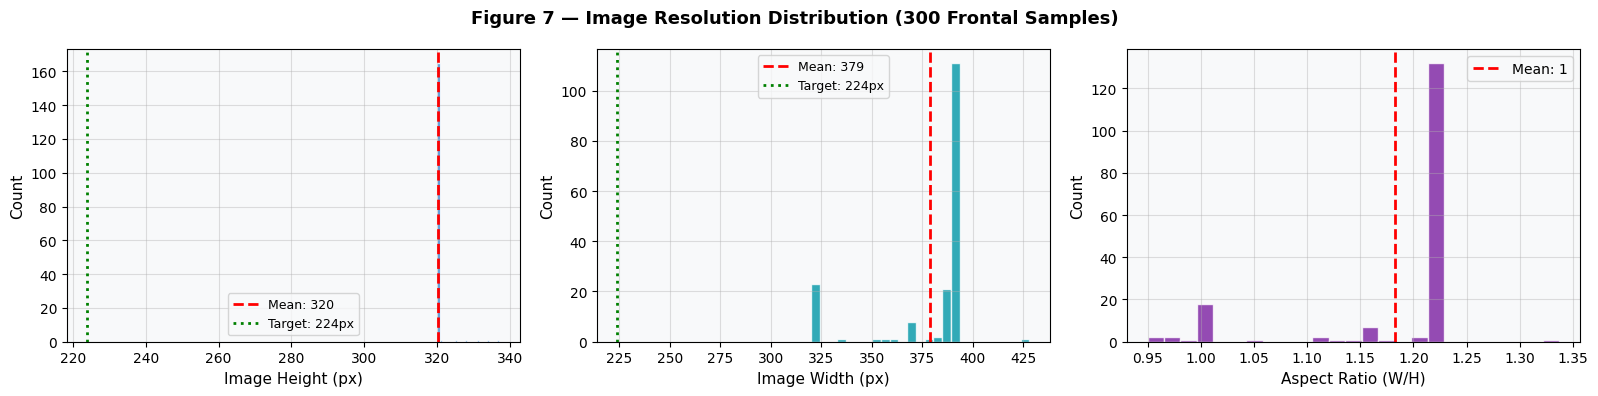

In [ ]:
# ─── Figure 7: Resolution Distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Figure 7 — Image Resolution Distribution (300 Frontal Samples)',
             fontsize=13, fontweight='bold')

for ax, data, label, color in zip(
    axes,
    [heights, widths, aspects],
    ['Image Height (px)', 'Image Width (px)', 'Aspect Ratio (W/H)'],
    ['#1976D2', '#0097A7', '#7B1FA2']
):
    ax.hist(data, bins=25, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(np.mean(data), color='red', linestyle='--',
               linewidth=2, label=f'Mean: {np.mean(data):.0f}')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.legend(fontsize=10)

# Mark 224 target on height and width plots
for ax in axes[:2]:
    ax.axvline(224, color='green', linestyle=':',
               linewidth=2, label='Target: 224px')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig7_resolution_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Class Imbalance Summary & Strategy

Class imbalance is a known challenge in medical imaging datasets. We summarise the imbalance ratios and define the strategy to address them in Notebook 2.

In [ ]:
# ─── Imbalance Ratio ─────────────────────────────────────────────────────────
print('  Class Imbalance Summary (Positive vs Non-Positive Ratio):\n')
print(f'{"Pathology":<35} {"Pos":>8} {"Non-Pos":>10} {"Ratio":>10} {"Strategy"}')
print('-' * 80)

for col in LABEL_COLS:
    pos     = (train_df[col] == 1.0).sum()
    non_pos = len(train_df) - pos
    ratio   = non_pos / pos if pos > 0 else float('inf')
    strategy = 'Class weights' if ratio > 5 else 'Balanced'
    print(f'{col:<35} {pos:>8,} {non_pos:>10,} {ratio:>9.1f}x   {strategy}')

print('\n Key findings:')
print('   • Pleural Effusion and Support Devices are the most frequent pathologies.')
print('   • Pneumonia, Lung Lesion, and Pleural Other are significantly rare.')
print('   → Mitigation: weighted Binary Cross-Entropy loss + class_weight parameter.')

  Class Imbalance Summary (Positive vs Non-Positive Ratio):

Pathology                                Pos    Non-Pos      Ratio Strategy
--------------------------------------------------------------------------------
No Finding                            22,381    201,033       9.0x   Class weights
Enlarged Cardiomediastinum            10,798    212,616      19.7x   Class weights
Cardiomegaly                          27,000    196,414       7.3x   Class weights
Lung Opacity                         105,581    117,833       1.1x   Balanced
Lung Lesion                            9,186    214,228      23.3x   Class weights
Edema                                 52,246    171,168       3.3x   Balanced
Consolidation                         14,783    208,631      14.1x   Class weights
Pneumonia                              6,039    217,375      36.0x   Class weights
Atelectasis                           33,376    190,038       5.7x   Class weights
Pneumothorax                          19,448 

---
## 13. Validation Set Analysis

The validation set contains **234 studies manually annotated by 5 board-certified radiologists** — this is the gold-standard evaluation set for CheXpert.

In [ ]:
# ─── Validation Set Overview ─────────────────────────────────────────────────
print(' Validation Set (Gold Standard — Radiologist Annotations):')
print(f'   Total studies : {len(valid_df)}')
print(f'   Columns       : {list(valid_df.columns)}')
print()
valid_df.head()

 Validation Set (Gold Standard — Radiologist Annotations):
   Total studies : 234
   Columns       : ['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']



,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/valid/patient64541/study1/...,Male,73,Frontal,AP,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Frontal,PA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,CheXpert-v1.0-small/valid/patient64542/study1/...,Male,70,Lateral,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,CheXpert-v1.0-small/valid/patient64543/study1/...,Male,85,Frontal,AP,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,CheXpert-v1.0-small/valid/patient64544/study1/...,Female,42,Frontal,AP,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


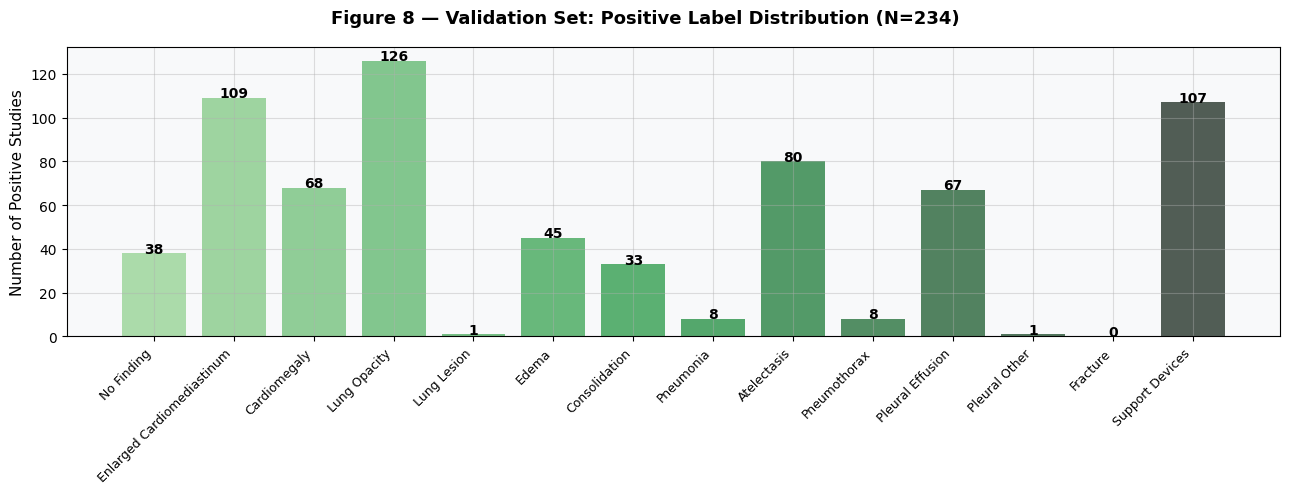

In [ ]:
# ─── Figure 8: Validation Set Label Distribution ─────────────────────────────
valid_label_cols = [c for c in LABEL_COLS if c in valid_df.columns]
val_pos = [(valid_df[c] == 1.0).sum() for c in valid_label_cols]

fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Figure 8 — Validation Set: Positive Label Distribution (N=234)',
             fontsize=13, fontweight='bold')

bars = ax.bar(valid_label_cols, val_pos,
              color=sns.color_palette('Greens_d', len(valid_label_cols)),
              alpha=0.85)
for bar, val in zip(bars, val_pos):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontweight='bold', fontsize=10)
ax.set_xticklabels(valid_label_cols, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of Positive Studies', fontsize=11)

plt.tight_layout()
plt.savefig('fig8_validation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 14. EDA Summary & Key Findings

The following findings directly inform the preprocessing and modelling decisions in subsequent notebooks.

In [ ]:
print('=' * 65)
print('  NOTEBOOK 1 — EDA COMPLETE: Key Findings')
print('=' * 65)
print()
print(' DATASET FACTS')
print(f'   Training studies            : {len(train_df):,}')
print(f'   Validation studies (gold)   : {len(valid_df):,}')
print(f'   Number of pathology labels  : 14 (multi-label)')
print(f'   View types                  : Frontal ({len(frontal_df):,}) + Lateral ({len(lateral_df):,})')
print()
print('  KEY CHALLENGES IDENTIFIED')
print('   1. MULTI-LABEL: Studies can have multiple simultaneous conditions.')
print('   2. UNCERTAINTY: ~X% of labels are uncertain (-1.0) → requires strategy.')
print('   3. CLASS IMBALANCE: Rare pathologies (Pneumonia, Lung Lesion, Fracture).')
print('   4. RESOLUTION VARIABILITY: Images range widely → standardize to 224×224.')
print('   5. LATERAL VIEWS: Excluded from training for consistency (frontal only).')
print()
print(' DECISIONS FOR NOTEBOOK 2 (Preprocessing)')
print('   • Filter: Keep only Frontal views.')
print('   • Uncertainty strategy: U-Zeros (map -1 → 0) — conservative baseline.')
print('   • Resize all images to 224×224 pixels.')
print('   • Normalize pixel values to [0, 1].')
print('   • Apply class weights to handle imbalance.')
print('   • Data augmentation: horizontal flip, rotation ±10°, zoom ±10%.')
print()


print('=' * 65)

  NOTEBOOK 1 — EDA COMPLETE: Key Findings

 DATASET FACTS
   Training studies            : 223,414
   Validation studies (gold)   : 234
   Number of pathology labels  : 14 (multi-label)
   View types                  : Frontal (191,027) + Lateral (32,387)

  KEY CHALLENGES IDENTIFIED
   1. MULTI-LABEL: Studies can have multiple simultaneous conditions.
   2. UNCERTAINTY: ~X% of labels are uncertain (-1.0) → requires strategy.
   3. CLASS IMBALANCE: Rare pathologies (Pneumonia, Lung Lesion, Fracture).
   4. RESOLUTION VARIABILITY: Images range widely → standardize to 224×224.
   5. LATERAL VIEWS: Excluded from training for consistency (frontal only).

 DECISIONS FOR NOTEBOOK 2 (Preprocessing)
   • Filter: Keep only Frontal views.
   • Uncertainty strategy: U-Zeros (map -1 → 0) — conservative baseline.
   • Resize all images to 224×224 pixels.
   • Normalize pixel values to [0, 1].
   • Apply class weights to handle imbalance.
   • Data augmentation: horizontal flip, rotation ±10°, zoom 

---

## References

1. Irvin, J., Rajpurkar, P., Ko, M., Yu, Y., Ciosi, S., Chute, C., ... & Ng, A. Y. (2019). **CheXpert: A Large Chest Radiograph Dataset with Uncertainty Labels and Expert Comparison.** *Proceedings of the AAAI Conference on Artificial Intelligence, 33*(01), 590–597. https://doi.org/10.1609/aaai.v33i01.3301590

2. Wang, X., Peng, Y., Lu, L., Lu, Z., Bagheri, M., & Summers, R. M. (2017). **ChestX-ray8: Hospital-scale Chest X-ray Database and Benchmarks.** *Proceedings of CVPR*, 2097–2106.

3. Rajpurkar, P., Irvin, J., Ball, R. L., Zhu, K., Yang, B., Mehta, H., ... & Lungren, M. P. (2017). **CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays with Deep Learning.** *arXiv preprint arXiv:1711.05225.*

---
